# 11 — Reranker + Single-Model (Mistral) + Corpus-Grounded Eval

Goal: improve the score ceiling.

1. **Decouple retrieval from generation** — tune retrieval cheaply (no generator roster).
2. **Add a cross-encoder reranker** (`BAAI/bge-reranker-v2-m3`, no API cost) — biggest free win for Context Precision.
3. **Single generator = Mistral-Large**
4. **Two ground truths, side by side**: the existing MedQA answers AND a NEW corpus-grounded set (reference answers written FROM the AWMF chunks).
5. **Dev on a 50-question subset**; full 200 only for the final number.

Reads the same `awmf_baseline_bge` collection and `AWMF_Golden_Dataset_200Q_Final.csv`.

## 1. Install dependencies

In [ ]:
!pip install -q ragas langchain langchain-openai langchain-huggingface psycopg2-binary pgvector langchain-postgres datasets nest_asyncio sentence-transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 466.5/466.5 kB 20.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.8/119.8 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.3/4.3 MB 73.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.5/48.5 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 91.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 557.4/557.4 kB 25.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 213.0/213.0 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.0/40.0 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 88.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 252.4/252.4 kB 15.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 65.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 

## 2. VertexAI import patch

In [ ]:
import sys, types
class DummyVertexAI: pass
class DummyChatVertexAI: pass
dummy_llms = types.ModuleType("langchain_community.llms"); dummy_llms.VertexAI = DummyVertexAI
sys.modules["langchain_community.llms"] = dummy_llms
dummy_chat_models = types.ModuleType("langchain_community.chat_models"); dummy_chat_models.ChatVertexAI = DummyChatVertexAI
sys.modules["langchain_community.chat_models"] = dummy_chat_models
dummy_chat_vertexai = types.ModuleType("langchain_community.chat_models.vertexai"); dummy_chat_vertexai.ChatVertexAI = DummyChatVertexAI
sys.modules["langchain_community.chat_models.vertexai"] = dummy_chat_vertexai
dummy_llms_vertexai = types.ModuleType("langchain_community.llms.vertexai"); dummy_llms_vertexai.VertexAI = DummyVertexAI
sys.modules["langchain_community.llms.vertexai"] = dummy_llms_vertexai

## 3. Setup: DB, embedder, reranker, models, config

In [ ]:
import os, json, time
import pandas as pd
import torch
import nest_asyncio
from google.colab import userdata, drive
from langchain_openai import ChatOpenAI
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_postgres import PGVector
from langchain_core.prompts import PromptTemplate
from sentence_transformers import CrossEncoder

nest_asyncio.apply()
drive.mount('/content/drive')

DRIVE_PATH = '/content/drive/MyDrive/'
DATASET_PATH = DRIVE_PATH + 'AWMF_Golden_Dataset_200Q_Final.csv'
df = pd.read_csv(DATASET_PATH)
print("Loaded", len(df), "rows. Columns:", list(df.columns))

NEON_CONNECTION_STRING = userdata.get('NEON_DATABASE_URL')
os.environ["OPENROUTER_API_KEY"] = userdata.get('OPENROUTER_API_KEY')

# Embedder + vector store (same collection, READ-ONLY)
bge_embeddings = HuggingFaceEmbeddings(model_name="BAAI/bge-m3", model_kwargs={'device': 'cpu'})
vector_store = PGVector(embeddings=bge_embeddings, collection_name="awmf_baseline_bge",
                        connection=NEON_CONNECTION_STRING, use_jsonb=True)

# Config knobs
K_RETRIEVE = 30   # wide net for the reranker to choose from
K_FINAL    = 8    # how many chunks actually go to the generator
USE_RERANKER = False
retriever = vector_store.as_retriever(search_kwargs={"k": K_RETRIEVE})

# Cross-encoder reranker (local, no API cost)
_device = "cuda" if torch.cuda.is_available() else "cpu"
print("Reranker device:", _device)
reranker = CrossEncoder("BAAI/bge-reranker-v2-m3", max_length=512, device=_device)

# Single generator = Mistral; judge = gpt-4o-mini (NOT the generator)
def make_llm(model, max_tokens=1024):
    return ChatOpenAI(model=model, api_key=os.environ["OPENROUTER_API_KEY"],
                      base_url="https://openrouter.ai/api/v1", temperature=0, max_tokens=max_tokens)

mistral   = make_llm("mistralai/mistral-large")
gt_author = make_llm("anthropic/claude-sonnet-4.6", max_tokens=600)  # one-time, for corpus-grounded answers

expansion_prompt = PromptTemplate(
    template="""You are an expert medical search term generator.
First, translate the following English medical question into German.
Then add 3-4 highly formal German clinical synonyms / related conditions / MeSH terms that would appear in a clinical guideline.
Output ONLY the German question plus the synonyms as a single continuous search string. No labels, no bullets.

English Question:
{question}""", input_variables=["question"])

qa_prompt = PromptTemplate(
    template="""You are an expert medical AI. Read the German clinical guidelines and answer the medical question in ENGLISH.
Use ONLY the provided German context. If the context does not contain the answer, say so plainly.

Context (German):
{context}

Question (English):
{question}

Answer (English):""", input_variables=["context", "question"])

gt_author_prompt = PromptTemplate(
    template="""You are building a reference answer key from official German AWMF guideline excerpts.
Using ONLY the excerpts below, write a concise, factual ENGLISH reference answer to the question.
Do NOT use outside knowledge. If the excerpts do not contain enough information, respond with exactly: NOT_IN_CORPUS

Excerpts (German):
{context}

Question (English):
{question}

Reference answer (English):""", input_variables=["context", "question"])

print("Setup complete.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded 200 rows. Columns: ['Disease', 'English_Open_Question', 'English_Correct_Text', 'German_Open_Question', 'German_Correct_Text']


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/123 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/15.8k [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/1.17k [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/964 [00:00<?, ?B/s]

Setup complete.


## 4. The single retrieval function (expand -> retrieve -> rerank)

In [ ]:
import time, random
def safe_invoke(llm, prompt, max_tries=8, base=8):
    for a in range(max_tries):
        try: return llm.invoke(prompt).content.strip()
        except Exception as e:
            if a == max_tries-1: raise
            w = min(base*(2**a)+random.uniform(0,3),120); print(f"retry {a+1}: waiting {w:.0f}s"); time.sleep(w)
# def expand_query(llm, q): return safe_invoke(llm, expansion_prompt.format(question=q))
# _gq = expand_query(mistral, df.iloc[0]['English_Open_Question'])
# print("OK:", _gq[:120])


OK: „58-jähriger Mann mit progredienter Dyspnoe und unproduktivem Husten seit einer Woche, vor drei Wochen fieberhafter Infe


In [ ]:
def expand_query(llm, english_question):
    return llm.invoke(expansion_prompt.format(question=english_question)).content.strip()

def retrieve_contexts(german_query, use_reranker=None, k_final=None):
    use_reranker = USE_RERANKER if use_reranker is None else use_reranker
    k_final = K_FINAL if k_final is None else k_final
    docs = retriever.invoke(german_query)          # K_RETRIEVE candidates
    texts = [d.page_content for d in docs]
    if use_reranker and texts:
        pairs = [[german_query, t] for t in texts]
        scores = reranker.predict(pairs)
        texts = [t for _, t in sorted(zip(scores, texts), key=lambda x: x[0], reverse=True)]
    return texts[:k_final]

# smoke test
_q = df.iloc[0]['English_Open_Question']
_gq = expand_query(mistral, _q)
print("Expanded:", _gq[:120], "...")
print("Top chunk:", retrieve_contexts(_gq)[0][:200], "...")

Expanded: „58-jähriger Patient stellt sich in der Notaufnahme mit progredienter Dyspnoe und unproduktivem Husten seit einer Woche  ...
Top chunk: logische Veränderung der Lungenfunktion 
Rhinitis, akut rezidivierende/chronische Sinusitis, Postnasal-Drip-
Syndrom 
Haltungs- oder Nahrungsmittelabhängige 
Symptome, vorherrschend Husten 
Gastro-öso ...


## 5. Build the corpus-grounded ground truth (one-time)

For each question we retrieve+rerank the AWMF chunks and ask a strong model to write a reference answer **using only those chunks**. Questions whose answer isn't in the corpus get `NOT_IN_CORPUS` — counting them gives a **corpus-coverage** number (a strong metric: what fraction of the benchmark is even answerable from the Top-10 AWMF guidelines).

In [ ]:
GT_FILE = DRIVE_PATH + "AWMF_CorpusGrounded_GroundTruth.csv"

if os.path.exists(GT_FILE):
    gt_df = pd.read_csv(GT_FILE); rows = gt_df.to_dict('records'); start = len(rows)
    print(f"Resuming corpus-GT build from {start}/{len(df)}")
else:
    rows = []; start = 0

for i in range(start, len(df)):
    r = df.iloc[i]; q = r['English_Open_Question']
    try:
        gq = expand_query(gt_author, q)
        ctx = retrieve_contexts(gq, use_reranker=True)
        ans = gt_author.invoke(gt_author_prompt.format(context="\n\n".join(ctx), question=q)).content.strip()
        rows.append({"English_Open_Question": q,
                     "medqa_ground_truth": r['English_Correct_Text'],
                     "corpus_ground_truth": ans})
        pd.DataFrame(rows).to_csv(GT_FILE, index=False)
        if (i+1) % 20 == 0:
            cov = sum(1 for x in rows if x['corpus_ground_truth'] != 'NOT_IN_CORPUS') / len(rows)
            print(f"{i+1}/{len(df)}  in-corpus coverage so far: {cov:.0%}")
        time.sleep(1.5)
    except Exception as e:
        print("err", i, e); time.sleep(5)

gt_df = pd.read_csv(GT_FILE)
coverage = (gt_df['corpus_ground_truth'] != 'NOT_IN_CORPUS').mean()
print(f"\nCORPUS COVERAGE: {coverage:.0%} of questions are answerable from the AWMF Top-10 corpus.")

20/200  in-corpus coverage so far: 20%
40/200  in-corpus coverage so far: 22%
60/200  in-corpus coverage so far: 27%
80/200  in-corpus coverage so far: 31%
100/200  in-corpus coverage so far: 33%
120/200  in-corpus coverage so far: 31%
140/200  in-corpus coverage so far: 30%
160/200  in-corpus coverage so far: 27%
180/200  in-corpus coverage so far: 26%
200/200  in-corpus coverage so far: 24%

CORPUS COVERAGE: 24% of questions are answerable from the AWMF Top-10 corpus.


## 6. Generate answers with Mistral (dev subset first)

`DEV = True` -> 50-question subset while iterating. Flip to `False` for the final 200-question run.

In [ ]:
DEV = True
DEV_N = 50

disease_col = next((c for c in df.columns if c.lower() in ("disease","condition","category","label")), None)
if DEV:
    if disease_col:
        per = max(1, DEV_N // max(1, df[disease_col].nunique()))
        work = df.groupby(disease_col, group_keys=False).apply(lambda g: g.sample(min(len(g), per), random_state=42)).head(DEV_N)
    else:
        work = df.sample(DEV_N, random_state=42)
else:
    work = df
print(f"Generating with Mistral on {len(work)} questions | reranker={USE_RERANKER} | k_final={K_FINAL}")

gt_df = pd.read_csv(DRIVE_PATH + "AWMF_CorpusGrounded_GroundTruth.csv")
gt_map = gt_df.set_index('English_Open_Question')['corpus_ground_truth'].to_dict()
tag = ("rerank" if USE_RERANKER else "norerank") + ("_dev" if DEV else "_full")
RES_FILE = DRIVE_PATH + f"MISTRAL_{tag}_results.json"
res = {"question": [], "answer": [], "contexts": [], "medqa_ground_truth": [], "corpus_ground_truth": []}

for i, r in work.reset_index(drop=True).iterrows():
    q = r['English_Open_Question']
    try:
        gq = expand_query(mistral, q)
        ctx = retrieve_contexts(gq)
        ans = mistral.invoke(qa_prompt.format(context="\n\n".join(ctx), question=q)).content.strip()
        res["question"].append(q); res["answer"].append(ans); res["contexts"].append(ctx)
        res["medqa_ground_truth"].append(r['English_Correct_Text'])
        res["corpus_ground_truth"].append(gt_map.get(q, "NOT_IN_CORPUS"))
        with open(RES_FILE, 'w') as f: json.dump(res, f)
        if (i+1) % 10 == 0: print(f"{i+1}/{len(work)}")
        time.sleep(1.5)
    except Exception as e:
        print("err", i, e); time.sleep(5)
print("Done ->", RES_FILE)

Generating with Mistral on 50 questions | reranker=False | k_final=8


/tmp/ipykernel_5183/3841360146.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  work = df.groupby(disease_col, group_keys=False).apply(lambda g: g.sample(min(len(g), per), random_state=42)).head(DEV_N)


10/50
20/50
30/50
40/50
50/50
Done -> /content/drive/MyDrive/MISTRAL_norerank_dev_results.json


## 7. RAGAS evaluation — side by side (MedQA GT vs Corpus-grounded GT)

Judge = `gpt-4o-mini` (cheap, NOT the generator). Same Mistral answers scored against both ground truths. Expect Context Recall / Faithfulness to jump under the corpus-grounded GT — that gap is the benchmark-mismatch effect.

In [ ]:
from datasets import Dataset, Features, Value, Sequence
from ragas import evaluate
from ragas.metrics import context_precision, context_recall, faithfulness, answer_relevancy
from ragas.llms import LangchainLLMWrapper
from ragas.embeddings import LangchainEmbeddingsWrapper
from ragas.run_config import RunConfig

judge_llm = LangchainLLMWrapper(make_llm("openai/gpt-4o-mini"))
ragas_embeddings = LangchainEmbeddingsWrapper(bge_embeddings)
feat = Features({"question":Value("string"),"answer":Value("string"),
                 "contexts":Sequence(Value("string")),"ground_truth":Value("string")})

with open(RES_FILE) as f: data = json.load(f)

def eval_with(gt_key, drop_not_in_corpus=False):
    rows = list(zip(data["question"], data["answer"], data["contexts"], data[gt_key]))
    if drop_not_in_corpus:
        rows = [r for r in rows if r[3] != "NOT_IN_CORPUS"]
    dd = {"question":[r[0] for r in rows],"answer":[r[1] for r in rows],
          "contexts":[r[2] for r in rows],"ground_truth":[r[3] for r in rows]}
    ds = Dataset.from_dict(dd, features=feat)
    out = evaluate(ds, metrics=[context_precision, context_recall, faithfulness, answer_relevancy],
                   llm=judge_llm, embeddings=ragas_embeddings,
                   run_config=RunConfig(timeout=300, max_workers=2, max_retries=5))
    return out.to_pandas()[["context_precision","context_recall","faithfulness","answer_relevancy"]].mean().round(3)

print("== Mistral vs MedQA ground truth ==")
print(eval_with("medqa_ground_truth"))
print("\n== Mistral vs CORPUS-GROUNDED ground truth (answerable subset) ==")
print(eval_with("corpus_ground_truth", drop_not_in_corpus=True))

/tmp/ipykernel_5183/3016796121.py:3: DeprecationWarning: Importing context_precision from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import context_precision
  from ragas.metrics import context_precision, context_recall, faithfulness, answer_relevancy
/tmp/ipykernel_5183/3016796121.py:3: DeprecationWarning: Importing context_recall from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import context_recall
  from ragas.metrics import context_precision, context_recall, faithfulness, answer_relevancy
/tmp/ipykernel_5183/3016796121.py:3: DeprecationWarning: Importing faithfulness from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import faithfulness
  from ragas.metrics import context_precis

== Mistral vs MedQA ground truth ==


Evaluating:   0%|          | 0/200 [00:00<?, ?it/s]

ERROR:ragas.executor:Exception raised in Job[2]: LLMDidNotFinishException(The LLM generation was not completed. Please increase the max_tokens and try again.)
ERROR:ragas.executor:Exception raised in Job[6]: LLMDidNotFinishException(The LLM generation was not completed. Please increase the max_tokens and try again.)
ERROR:ragas.executor:Exception raised in Job[10]: LLMDidNotFinishException(The LLM generation was not completed. Please increase the max_tokens and try again.)
ERROR:ragas.executor:Exception raised in Job[18]: LLMDidNotFinishException(The LLM generation was not completed. Please increase the max_tokens and try again.)
ERROR:ragas.executor:Exception raised in Job[22]: LLMDidNotFinishException(The LLM generation was not completed. Please increase the max_tokens and try again.)
ERROR:ragas.executor:Exception raised in Job[26]: LLMDidNotFinishException(The LLM generation was not completed. Please increase the max_tokens and try again.)
ERROR:ragas.executor:Exception raised in J

context_precision    0.160
context_recall       0.180
faithfulness         0.502
answer_relevancy     0.265
dtype: float64

== Mistral vs CORPUS-GROUNDED ground truth (answerable subset) ==


Evaluating:   0%|          | 0/56 [00:00<?, ?it/s]

ERROR:ragas.executor:Exception raised in Job[2]: LLMDidNotFinishException(The LLM generation was not completed. Please increase the max_tokens and try again.)
ERROR:ragas.executor:Exception raised in Job[6]: LLMDidNotFinishException(The LLM generation was not completed. Please increase the max_tokens and try again.)
ERROR:ragas.executor:Exception raised in Job[10]: LLMDidNotFinishException(The LLM generation was not completed. Please increase the max_tokens and try again.)
ERROR:ragas.executor:Exception raised in Job[14]: LLMDidNotFinishException(The LLM generation was not completed. Please increase the max_tokens and try again.)
ERROR:ragas.executor:Exception raised in Job[18]: LLMDidNotFinishException(The LLM generation was not completed. Please increase the max_tokens and try again.)
ERROR:ragas.executor:Exception raised in Job[22]: LLMDidNotFinishException(The LLM generation was not completed. Please increase the max_tokens and try again.)
ERROR:ragas.executor:Exception raised in J

context_precision    0.837
context_recall       0.681
faithfulness         0.571
answer_relevancy     0.498
dtype: float64


## 8. (Optional) Cheap retrieval-only sweep — NO generation

Context Precision/Recall barely depend on the generator, so tune `K_FINAL` / reranker on-off here without burning Mistral tokens (only the judge runs). Lock retrieval first, then run sections 6-7 once.

In [ ]:
def retrieval_only(work_df, use_reranker, k_final):
    rows = {"question":[],"answer":[],"contexts":[],"ground_truth":[]}
    for _, r in work_df.iterrows():
        q = r['English_Open_Question']; gtv = gt_map.get(q, "NOT_IN_CORPUS")
        if gtv == "NOT_IN_CORPUS": continue
        gq = expand_query(mistral, q)
        ctx = retrieve_contexts(gq, use_reranker=use_reranker, k_final=k_final)
        rows["question"].append(q); rows["answer"].append(""); rows["contexts"].append(ctx); rows["ground_truth"].append(gtv)
        time.sleep(1)
    ds = Dataset.from_dict(rows, features=feat)
    out = evaluate(ds, metrics=[context_precision, context_recall], llm=judge_llm,
                   embeddings=ragas_embeddings, run_config=RunConfig(timeout=300, max_workers=2, max_retries=5))
    return out.to_pandas()[["context_precision","context_recall"]].mean().round(3)

sample = df.sample(40, random_state=7)
for ur in (False, True):
    print(f"reranker={ur}:", dict(retrieval_only(sample, use_reranker=ur, k_final=K_FINAL)))

Evaluating:   0%|          | 0/18 [00:00<?, ?it/s]

reranker=False: {'context_precision': np.float64(0.778), 'context_recall': np.float64(0.844)}


Evaluating:   0%|          | 0/18 [00:00<?, ?it/s]

reranker=True: {'context_precision': np.float64(0.778), 'context_recall': np.float64(0.884)}


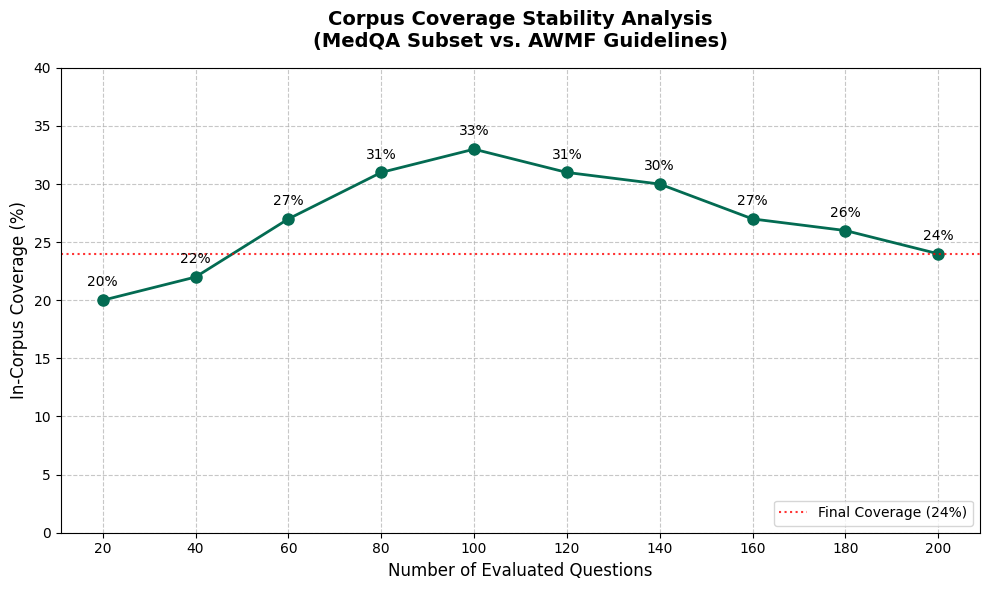

In [1]:
import matplotlib.pyplot as plt

# Data from your notebook execution
questions = [20, 40, 60, 80, 100, 120, 140, 160, 180, 200]
coverage = [20, 22, 27, 31, 33, 31, 30, 27, 26, 24]

# Set up the plot style
plt.figure(figsize=(10, 6))
plt.plot(questions, coverage, marker='o', linestyle='-', color='#036b52', linewidth=2, markersize=8)

# Add titles and labels
plt.title('Corpus Coverage Stability Analysis\n(MedQA Subset vs. AWMF Guidelines)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Number of Evaluated Questions', fontsize=12)
plt.ylabel('In-Corpus Coverage (%)', fontsize=12)

# Set axis limits and ticks
plt.ylim(0, 40)
plt.xticks(questions)
plt.yticks(range(0, 45, 5))

# Add a grid for readability
plt.grid(True, linestyle='--', alpha=0.7)

# Add data labels to the points
for i, txt in enumerate(coverage):
    plt.annotate(f'{txt}%', (questions[i], coverage[i]), textcoords="offset points", xytext=(0,10), ha='center', fontsize=10)

# Add a horizontal line representing the final 24% baseline
plt.axhline(y=24, color='r', linestyle=':', alpha=0.8, label='Final Coverage (24%)')
plt.legend(loc='lower right')

# Save the plot at high resolution for LaTeX
plt.tight_layout()
plt.savefig('corpus_coverage_chart.png', dpi=300)